In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [3]:
## Utils: Check for missing values
(train_data == 'None').any().any()

print("NaN values:", train_data.isnull().sum().sum())

missing = train_data.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

NaN values: 7829
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


# Data Preprocessing

## Missing Data Handling
1. Check the missing data, some "NA" means None, like basement and garage, pool related...
2. Electrical in train data, drop the missing rows, just a few
3. LotFrontage is related to Neighborhood, fillna with Neighborhood median

In [4]:
replace_na_cols = train_data.columns[train_data.columns.str.startswith(('Bsmt', 'Garage', 'MasVnr'))].to_list() + ['FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature', 'Alley']

for c in replace_na_cols:
    if pd.api.types.is_numeric_dtype(train_data[c]):
        train_data[c] = train_data[c].fillna(0)
        test_data[c] = test_data[c].fillna(0)
    else:
        train_data[c] = train_data[c].fillna('NA')
        test_data[c] = test_data[c].fillna('NA')
train_data['LotFrontage'] = train_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

train_data = train_data.dropna(subset=['Electrical'])

In [5]:
missing = test_data.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))
test_data['KitchenQual'] = test_data.groupby('KitchenAbvGr')['KitchenQual'].transform(lambda x: x.fillna(x.mode()[0]))
test_data['LotFrontage'] = test_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_data['Functional'] = test_data['Functional'].fillna('Typ')
test_data['TotalBsmtSF'] = test_data['TotalBsmtSF'].fillna(0)
test_data[['Exterior1st', 'Exterior2nd', 'SaleType']] = test_data[['Exterior1st', 'Exterior2nd', 'SaleType']].fillna('Other')

test_data['MSZoning'] = test_data.groupby('MSSubClass')['MSZoning'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else train_data['MSZoning'].mode()[0])
)

LotFrontage    227
MSZoning         4
Utilities        2
Functional       2
Exterior1st      1
Exterior2nd      1
TotalBsmtSF      1
KitchenQual      1
SaleType         1
dtype: int64


## Detection of Useless features, all dominant

In [6]:
for col in train_data.select_dtypes(include='object').columns:
    top_ratio = train_data[col].value_counts(normalize=True).iloc[0]
    if top_ratio > 0.95:
        print(f"{col}: {top_ratio:.3f}  ({train_data[col].value_counts().to_dict()})")

# just 1 different row, mean not meaningfully different
train_data.groupby('Utilities')['SalePrice'].agg(['mean', 'count'])

Street: 0.996  ({'Pave': 1453, 'Grvl': 6})
Utilities: 0.999  ({'AllPub': 1458, 'NoSeWa': 1})
Condition2: 0.990  ({'Norm': 1444, 'Feedr': 6, 'Artery': 2, 'RRNn': 2, 'PosN': 2, 'PosA': 1, 'RRAn': 1, 'RRAe': 1})
RoofMatl: 0.982  ({'CompShg': 1433, 'Tar&Grv': 11, 'WdShngl': 6, 'WdShake': 5, 'Metal': 1, 'Membran': 1, 'Roll': 1, 'ClyTile': 1})
Heating: 0.978  ({'GasA': 1427, 'GasW': 18, 'Grav': 7, 'Wall': 4, 'OthW': 2, 'Floor': 1})
PoolQC: 0.995  ({'NA': 1452, 'Gd': 3, 'Ex': 2, 'Fa': 2})
MiscFeature: 0.963  ({'NA': 1405, 'Shed': 49, 'Gar2': 2, 'Othr': 2, 'TenC': 1})


/var/folders/0_/kmvsm8cx3nv69xrnhj27m1vr0000gn/T/ipykernel_74898/2586537447.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train_data.select_dtypes(include='object').columns:


,mean,count
Utilities,,
AllPub,180960.182442,1458
NoSeWa,137500.000000,1


In [7]:
train_data = train_data.drop(columns=['Utilities'])
test_data = test_data.drop(columns=['Utilities'])

## Data Patterns Observe

1.8819429948035529


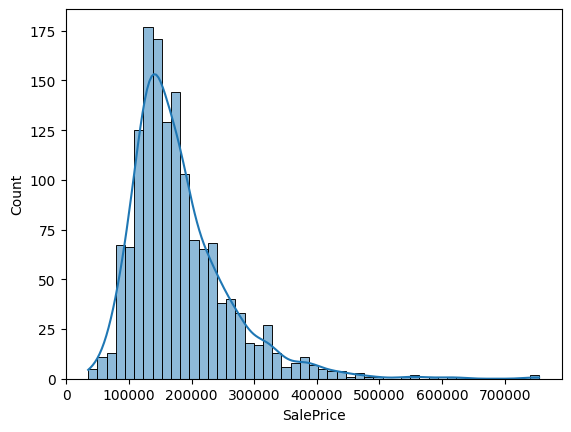

In [8]:
sns.histplot(train_data['SalePrice'], kde=True)
print(train_data['SalePrice'].skew())  # ~1.88 — right-skewed
train_data['SalePrice_Log'] = np.log(train_data['SalePrice'])

In [9]:
num_cols = train_data.select_dtypes(include='number').columns.drop(['Id', 'SalePrice'])
skew = train_data[num_cols].skew().sort_values(ascending=False)
print(skew[abs(skew) > 0.75])
cols_apply_log = []
for col in skew[abs(skew) > 0.75].index:
    zero_pct = (train_data[col] == 0).mean()
    if zero_pct<0.3:
        cols_apply_log += [col]
        train_data[col] = np.log1p(train_data[col])
        test_data[col] = np.log1p(test_data[col])
print(f"Applied log1p to: {cols_apply_log}")

MiscVal          24.468441
PoolArea         14.823236
LotArea          12.203431
3SsnPorch        10.300725
LowQualFinSF      9.008149
KitchenAbvGr      4.486640
BsmtFinSF2        4.253594
ScreenPorch       4.120572
BsmtHalfBath      4.101759
EnclosedPorch     3.088518
MasVnrArea        2.676551
OpenPorchSF       2.363530
LotFrontage       2.212494
BsmtFinSF1        1.685198
WoodDeckSF        1.540947
TotalBsmtSF       1.526760
MSSubClass        1.408620
1stFlrSF          1.376504
GrLivArea         1.365701
BsmtUnfSF         0.919312
2ndFlrSF          0.814303
GarageYrBlt      -3.867940
dtype: float64
Applied log1p to: ['LotArea', 'KitchenAbvGr', 'LotFrontage', 'TotalBsmtSF', 'MSSubClass', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', 'GarageYrBlt']


In [10]:
# --- Ordinal encoding -------------------------------------------------------
## 0 = feature absent (your missing-data step filled the
# Bsmt/Garage/Pool/Fence/FireplaceQu columns with 'None'), then Po -> Ex.

qual_map = {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
]
for col in qual_cols:
    train_data[col] = train_data[col].map(qual_map)
    test_data[col] = test_data[col].map(qual_map)

ordinal_maps = {
    'BsmtExposure': {'NA': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Functional':   {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'Fence':        {'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'LotShape':     {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'LandSlope':    {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
    'CentralAir':   {'N': 0, 'Y': 1},
}
for col, mapping in ordinal_maps.items():
    train_data[col] = train_data[col].map(mapping)
    test_data[col] = test_data[col].map(mapping)

# Linear Model

1. One-hot encode the remaining categorical features
2. Align train/test columns so they share the same feature space
3. Fit `LinearRegression` on `SalePrice_Log`, validate with RMSE (the Kaggle metric)
4. Refit on all training data and write a submission

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Prepare data — one-hot encode and align train/test
train_dummies = pd.get_dummies(train_data.drop(columns=['SalePrice', 'SalePrice_Log', 'Id']))
test_dummies = pd.get_dummies(test_data.drop(columns=['Id']))

# Align columns (test may have different dummy cols)
train_dummies, test_dummies = train_dummies.align(test_dummies, join='inner', axis=1)

# Target
y = train_data['SalePrice_Log']

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(train_dummies)
X_test = scaler.transform(test_dummies)

print(f"Training features: {X.shape[1]} columns, {X.shape[0]} rows")


Training features: 209 columns, 1459 rows


In [12]:
## 1. Basic Linear Regression
lr = LinearRegression()
lr_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"Linear Regression RMSE:    {-lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

## 2. Ridge Regression
ridge = Ridge(alpha=10)
ridge_scores = cross_val_score(ridge, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"Ridge (alpha=10) RMSE:    {-ridge_scores.mean():.4f} (+/- {ridge_scores.std():.4f})")

## 3. Lasso Regression
lasso = Lasso(alpha=0.001)
lasso_scores = cross_val_score(lasso, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"Lasso (alpha=0.001) RMSE:  {-lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")

## 4. ElasticNet (combines L1 + L2 penalties)
enet = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet_scores = cross_val_score(enet, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(f"ElasticNet (a=0.001) RMSE: {-enet_scores.mean():.4f} (+/- {enet_scores.std():.4f})")


Linear Regression RMSE:    0.1470 (+/- 0.0138)
Ridge (alpha=10) RMSE:    0.1421 (+/- 0.0144)
Lasso (alpha=0.001) RMSE:  0.1344 (+/- 0.0155)
ElasticNet (a=0.001) RMSE: 0.1383 (+/- 0.0148)


In [13]:
## Fit Lasso on full training data and predict
lasso_final = Lasso(alpha=0.001)
lasso_final.fit(X, y)

# Predict on test set (reverse log transform)
predictions_log = lasso_final.predict(X_test)
predictions = np.exp(predictions_log)  # reverse np.log

# Create submission
submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"\nSubmission saved: {submission.shape[0]} predictions")
print(f"Price range: ${predictions.min():,.0f} - ${predictions.max():,.0f}")


     Id      SalePrice
0  1461  115856.883145
1  1462  156447.502090
2  1463  180377.832002
3  1464  196602.900630
4  1465  203348.435059
5  1466  168651.254042
6  1467  177974.175813
7  1468  161981.659615
8  1469  193878.682314
9  1470  121016.527727

Submission saved: 1459 predictions
Price range: $37,755 - $623,413


In [14]:
# Train RMSE (for overfitting check)
from sklearn.metrics import mean_squared_error
train_pred = lasso_final.predict(X)
train_rmse = np.sqrt(mean_squared_error(y, train_pred))
print(f"Train RMSE: {train_rmse:.4f} vs CV RMSE: 0.1306")
# If train << CV → overfitting. If train ≈ CV → good fit.

# How many features Lasso kept
n_used = np.sum(lasso_final.coef_ != 0)
print(f"Features used: {n_used}/{X.shape[1]}")

# Top 10 most important features
coef_df = pd.Series(lasso_final.coef_, index=train_dummies.columns)
coef_df.abs().sort_values(ascending=False).head(10)


Train RMSE: 0.1040 vs CV RMSE: 0.1306
Features used: 151/209


GrLivArea               0.098472
OverallQual             0.066304
1stFlrSF                0.039951
OverallCond             0.039763
YearBuilt               0.038667
LotArea                 0.036234
RoofMatl_CompShg        0.033588
GarageCars              0.032803
MSZoning_C (all)        0.032540
Neighborhood_NridgHt    0.026770
dtype: float64

In [15]:
## Lasso Model Summary
from sklearn.metrics import r2_score

print("=" * 50)
print("LASSO REGRESSION SUMMARY")
print("=" * 50)
print(f"Alpha (regularization):  {lasso_final.alpha}")
print(f"Total features:          {X.shape[1]}")
print(f"Non-zero coefficients:   {n_used} ({n_used/X.shape[1]*100:.1f}%)")
print(f"Zeroed-out features:     {X.shape[1] - n_used}")
print(f"Training samples:        {X.shape[0]}")
print()
print(f"Train RMSE:              {train_rmse:.4f}")
print(f"CV RMSE (5-fold):        {-lasso_scores.mean():.4f} (+/- {lasso_scores.std():.4f})")
print(f"Train R²:                {r2_score(y, train_pred):.4f}")
print()
print("Top 10 features (by |coefficient|):")
print(coef_df.abs().sort_values(ascending=False).head(10))

# Quick summary table of coefficients
coef_summary = pd.DataFrame({
    'feature': train_dummies.columns,
    'coefficient': lasso_final.coef_
}).sort_values('coefficient', key=abs, ascending=False)
coef_summary[coef_summary['coefficient'] != 0]  # Only non-zero


LASSO REGRESSION SUMMARY
Alpha (regularization):  0.001
Total features:          209
Non-zero coefficients:   151 (72.2%)
Zeroed-out features:     58
Training samples:        1459

Train RMSE:              0.1040
CV RMSE (5-fold):        0.1344 (+/- 0.0155)
Train R²:                0.9323

Top 10 features (by |coefficient|):
GrLivArea               0.098472
OverallQual             0.066304
1stFlrSF                0.039951
OverallCond             0.039763
YearBuilt               0.038667
LotArea                 0.036234
RoofMatl_CompShg        0.033588
GarageCars              0.032803
MSZoning_C (all)        0.032540
Neighborhood_NridgHt    0.026770
dtype: float64


,feature,coefficient
26,GrLivArea,0.098472
5,OverallQual,0.066304
23,1stFlrSF,0.039951
6,OverallCond,0.039763
7,YearBuilt,0.038667
...,...,...
107,Condition1_RRNe,-0.000175
155,Exterior2nd_HdBoard,-0.000119
185,GarageType_Basment,-0.000095
10,ExterQual,0.000092


# Tree Model

In [16]:
import numpy as np
from sklearn.model_selection import cross_val_score

# Trees split on thresholds, so no StandardScaler. Use the aligned dummies directly.
X_tree = train_dummies      
X_test_tree = test_dummies
# y = train_df['SalePrice_Log']  # same log target as before

def cv_rmse(model, X=X_tree, y=y):
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    return -scores.mean(), scores.std()


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, max_features='sqrt',
                           random_state=42, n_jobs=-1)
m, s = cv_rmse(rf)
print(f"RandomForest RMSE: {m:.4f} (+/- {s:.4f})")


RandomForest RMSE: 0.1420 (+/- 0.0101)


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=2000, learning_rate=0.01,
                                max_depth=3, subsample=0.8, random_state=42)
m, s = cv_rmse(gbr)
print(f"GradientBoosting RMSE: {m:.4f} (+/- {s:.4f})")


GradientBoosting RMSE: 0.1184 (+/- 0.0104)


In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(learning_rate=0.05, max_iter=1000,
                                    max_depth=3, l2_regularization=1.0,
                                    random_state=42)
m, s = cv_rmse(hgb)
print(f"HistGradientBoosting RMSE: {m:.4f} (+/- {s:.4f})")


HistGradientBoosting RMSE: 0.1262 (+/- 0.0067)


If XGBRegressor can't be installed correctly, command below:

/bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"

brew install libomp

In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=2000, learning_rate=0.01, max_depth=3,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)
m, s = cv_rmse(xgb)
print(f"XGBoost RMSE: {m:.4f} (+/- {s:.4f})")


XGBoost RMSE: 0.1200 (+/- 0.0108)


In [22]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=2000, learning_rate=0.01, num_leaves=15,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
m, s = cv_rmse(lgbm)
print(f"LightGBM RMSE: {m:.4f} (+/- {s:.4f})")


LightGBM RMSE: 0.1271 (+/- 0.0089)


In [23]:
best = gbr                       # e.g. LightGBM
best.fit(X_tree, y)

preds = np.exp(best.predict(X_test_tree))   # reverse np.log
submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': preds})
submission.to_csv('submission_tree.csv', index=False)
print(submission.head())


     Id      SalePrice
0  1461  123322.709196
1  1462  157846.599051
2  1463  184192.232174
3  1464  187264.353738
4  1465  191794.238597


In [24]:
# Model Blending (simple average of predictions)

# Fit both on the full data, then average in log space.
lasso_final.fit(X, y)                  # X = your SCALED features
best.fit(X_tree, y)                    # tree uses UNSCALED features

pred_lasso = lasso_final.predict(X_test)       # scaled test set
pred_tree  = best.predict(X_test_tree)         # unscaled test set
blend = np.exp(0.5 * pred_lasso + 0.5 * pred_tree)

pd.DataFrame({'Id': test_data['Id'], 'SalePrice': blend}).to_csv('submission_blend.csv', index=False)


In [25]:
# How to tune tree-based models bleeds weight
from sklearn.model_selection import cross_val_predict

# Out-of-fold predictions in log space (each row predicted by a fold that excluded it).
# Note the two different feature matrices: Lasso uses scaled X, tree uses unscaled X_tree.
oof_lasso = cross_val_predict(lasso_final, X,      y, cv=5)
oof_tree  = cross_val_predict(best,        X_tree, y, cv=5)

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

for w in np.arange(0, 1.01, 0.05):
    blend = w * oof_lasso + (1 - w) * oof_tree
    print(f"w_lasso={w:.2f}  RMSE={rmse(y, blend):.4f}")


w_lasso=0.00  RMSE=0.1188
w_lasso=0.05  RMSE=0.1182
w_lasso=0.10  RMSE=0.1177
w_lasso=0.15  RMSE=0.1174
w_lasso=0.20  RMSE=0.1173
w_lasso=0.25  RMSE=0.1173
w_lasso=0.30  RMSE=0.1174
w_lasso=0.35  RMSE=0.1178
w_lasso=0.40  RMSE=0.1182
w_lasso=0.45  RMSE=0.1189
w_lasso=0.50  RMSE=0.1197
w_lasso=0.55  RMSE=0.1206
w_lasso=0.60  RMSE=0.1217
w_lasso=0.65  RMSE=0.1230
w_lasso=0.70  RMSE=0.1243
w_lasso=0.75  RMSE=0.1258
w_lasso=0.80  RMSE=0.1275
w_lasso=0.85  RMSE=0.1292
w_lasso=0.90  RMSE=0.1311
w_lasso=0.95  RMSE=0.1331
w_lasso=1.00  RMSE=0.1352


In [26]:
from sklearn.linear_model import LinearRegression

meta_X = np.column_stack([oof_lasso, oof_tree])
meta = LinearRegression().fit(meta_X, y)
print("weights:", meta.coef_, "intercept:", meta.intercept_)


weights: [0.22416036 0.7862116 ] intercept: -0.12434021673675133


In [29]:
meta = LinearRegression(positive=True).fit(meta_X, y)
meta_test_X = np.column_stack([pred_lasso, pred_tree])
blend = np.exp(meta.predict(meta_test_X))

pd.DataFrame({'Id': test_data['Id'], 'SalePrice': blend}).to_csv('submission_blend_optimal.csv', index=False)
print(f"weights: lasso={meta.coef_[0]:.4f}, tree={meta.coef_[1]:.4f}, intercept={meta.intercept_:.4f}")
print(f"price range: ${blend.min():,.0f} - ${blend.max():,.0f}")

weights: lasso=0.2242, tree=0.7862, intercept=-0.1243
price range: $35,320 - $558,961


In [27]:
opt_lasso_weight = meta.coef_[0]
opt_tree_weight = meta.coef_[1]
print(f"Optimal weights: Lasso={opt_lasso_weight:.4f}, Tree={opt_tree_weight:.4f}")
blend = np.exp(opt_lasso_weight * pred_lasso + opt_tree_weight * pred_tree)

pd.DataFrame({'Id': test_data['Id'], 'SalePrice': blend}).to_csv('submission_blend_optimal.csv', index=False)


Optimal weights: Lasso=0.2242, Tree=0.7862
